# Transient & MCMC II: nested sempling

Let's study transient fenomena with the use of MCMC and nested-sempling technique.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import dynesty

In [2]:
data = np.load("../Solutions/transient.npy")
time, flux, error = data.T

In [3]:
# Define the model
def Model(t, b, A, alpha, t0):
    return np.where(t < t0, b, b + A * np.exp(-alpha * (t - t0)))

# Define the log-likelihood
def logLikelihood(theta, t, flux, error):
    b, A, alpha, t0 = theta
    model = Model(t, b, A, alpha, t0)
    logL = -0.5 * np.sum(((flux - model) / error) ** 2)
    return logL

# Define the prior transformation
def priorTransform(u):
    b = 50 * u[0]  # Map u[0] from [0, 1] to [0, 50]
    A = 50 * u[1]  # Map u[1] from [0, 1] to [0, 50]
    logalpha = -5 + 10 * u[2]  # Map u[2] from [0, 1] to [-5, 5]
    t0 = 100 * u[3]  # Map u[3] from [0, 1] to [0, 100]

    alpha = np.exp(logalpha)  # Convert logalpha to alpha

    return b, A, alpha, t0

In [4]:
ndim = 4
sampler = dynesty.NestedSampler(logLikelihood, priorTransform, ndim, nlive = 500, logl_args=(time, flux, error))
sampler.run_nested()
samples = sampler.results['samples']

/var/folders/y3/hmkzfhj13553n22ygq7syz5r0000gn/T/ipykernel_31819/269179680.py:3: RuntimeWarning: overflow encountered in exp
  return np.where(t < t0, b, b + A * np.exp(-alpha * (t - t0)))
/var/folders/y3/hmkzfhj13553n22ygq7syz5r0000gn/T/ipykernel_31819/269179680.py:3: RuntimeWarning: overflow encountered in multiply
  return np.where(t < t0, b, b + A * np.exp(-alpha * (t - t0)))
1844it [00:00, 2600.47it/s, bound: 0 | nc: 13 | ncall: 17358 | eff(%): 10.623 | loglstar:   -inf < -169.193 <    inf | logz: -177.453 +/-  0.122 | dlogz: 117.167 >  0.509]/var/folders/y3/hmkzfhj13553n22ygq7syz5r0000gn/T/ipykernel_31819/269179680.py:3: RuntimeWarning: overflow encountered in exp
  return np.where(t < t0, b, b + A * np.exp(-alpha * (t - t0)))
/var/folders/y3/hmkzfhj13553n22ygq7syz5r0000gn/T/ipykernel_31819/269179680.py:3: RuntimeWarning: overflow encountered in multiply
  return np.where(t < t0, b, b + A * np.exp(-alpha * (t - t0)))
/var/folders/y3/hmkzfhj13553n22ygq7syz5r0000gn/T/ipykernel_3181

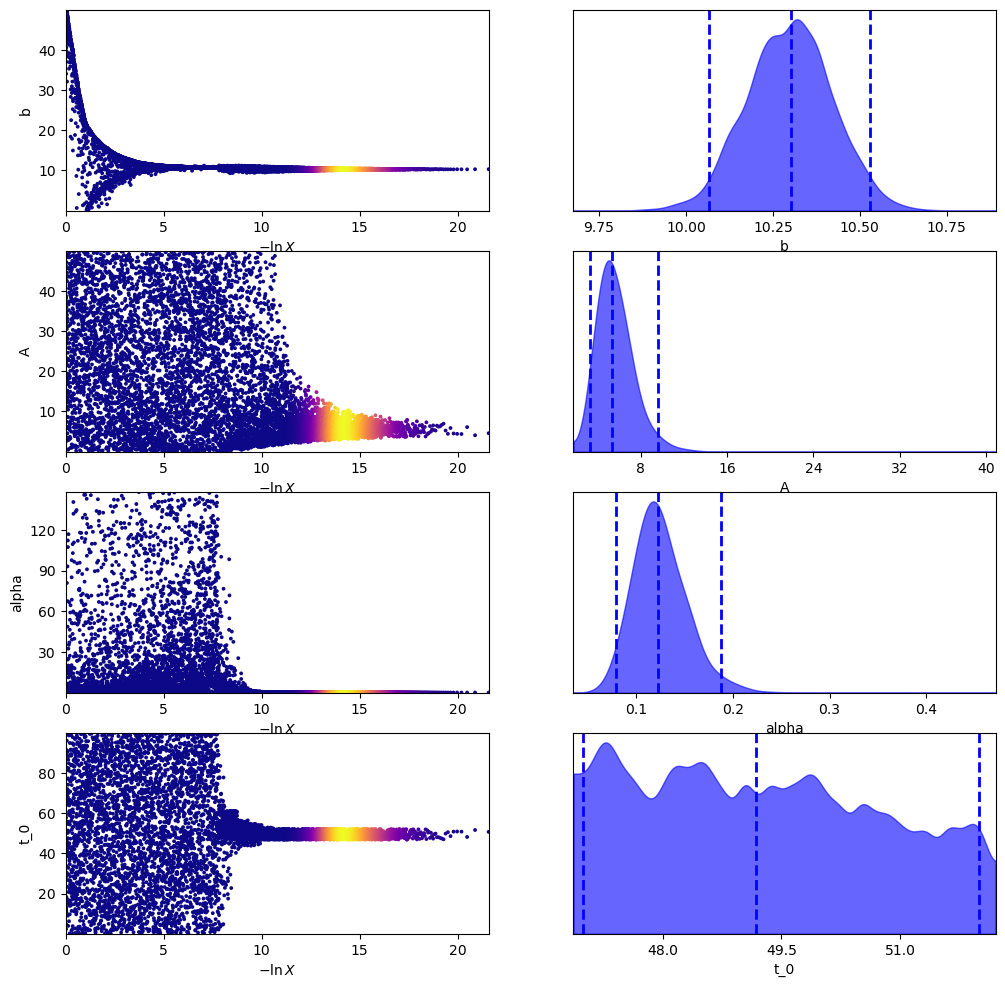

In [5]:
from dynesty import plotting as dyplot

labels = ["b", "A", "alpha", "t_0"]
fig, axes = dyplot.traceplot(sampler.results, labels=labels)
plt.show()

Seems that the method did well. 

Remember, samples are always weighted.

In [6]:
from dynesty import utils as dyfunc

weights = np.exp(sampler.results['logwt'] - sampler.results['logz'][-1])
samples_equal = dyfunc.resample_equal(samples, weights)

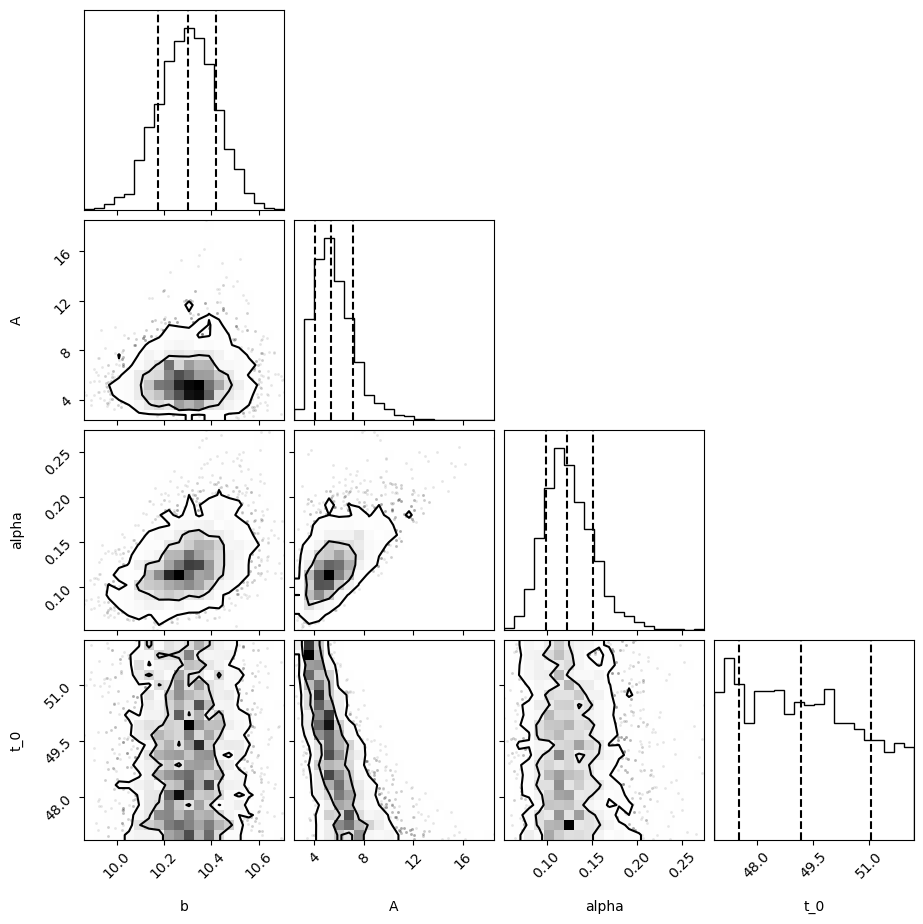

In [7]:
import corner as corner

fig = corner.corner(
    samples_equal, 
    labels=labels, 
    levels=[0.68, 0.95],
    quantiles=[0.16, 0.5, 0.84]
)
plt.show()

In [8]:
median_params = np.median(samples_equal, axis=0)
percentiles_params = np.percentile(samples_equal, [5, 95], axis=0)

print("Parameter estimates:")
for i, param in enumerate(labels):
    print(f"{param}: {median_params[i]:.3f} (+{percentiles_params[1, i] - median_params[i]:.3f}, -{median_params[i] - percentiles_params[0, i]:.3f})")

Parameter estimates:
b: 10.301 (+0.196, -0.198)
A: 5.356 (+3.375, -1.870)
alpha: 0.122 (+0.051, -0.037)
t_0: 49.170 (+2.656, -2.073)


The fact that samples are limited give an underestimeted error. One should run for instance a Bootstrap.

### Try another Model

Let's see how evidence helps us select the best model

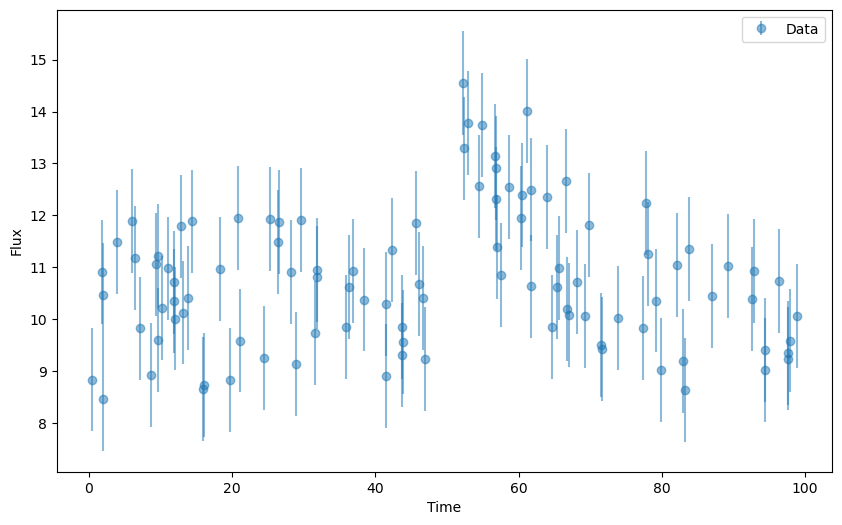

In [9]:
plt.figure(figsize=(10, 6))
plt.errorbar(time, flux, yerr=error, fmt='o', label='Data', alpha=0.5)
plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.show()

In [10]:
# Define the model
def Model(t, b, A, sigma, t0):
    return  b + A * np.exp(-0.5 * ((t - t0) / sigma) ** 2)

# Define the log-likelihood
def logLikelihood(theta, t, flux, error):
    b, A, sigma, t0 = theta
    model = Model(t, b, A, sigma, t0)
    logL = -0.5 * np.sum(((flux - model) / error) ** 2)
    return logL

# Define the prior transformation
def priorTransform(u):
    b = 50 * u[0]  # Map u[0] from [0, 1] to [0, 50]
    A = 50 * u[1]  # Map u[1] from [0, 1] to [0, 50]
    sigma = 50 * u[2]  # Map u[2] from [0, 1] to [0, 50]
    t0 = 100 * u[3]  # Map u[3] from [0, 1] to [0, 100]
    return b, A, sigma, t0

In [11]:
gauss_sampler = dynesty.NestedSampler(logLikelihood, priorTransform, ndim, nlive = 500, logl_args=(time, flux, error))
gauss_sampler.run_nested()
gauss_samples = gauss_sampler.results['samples']

1451it [00:00, 4494.33it/s, bound: 0 | nc: 30 | ncall: 8362 | eff(%): 17.352 | loglstar:   -inf < -1496.874 <    inf | logz: -1506.086 +/-  0.133 | dlogz: 1423.045 >  0.509] /opt/anaconda3/envs/astrostats/lib/python3.11/site-packages/dynesty/bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
3822it [00:09, 113.94it/s, bound: 44 | nc: 163 | ncall: 51289 | eff(%):  7.452 | loglstar:   -inf < -88.458 <    inf | logz: -98.037 +/-  0.132 | dlogz: 37.599 >  0.509]    /opt/anaconda3/envs/astrostats/lib/python3.11/site-packages/dynesty/bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootst

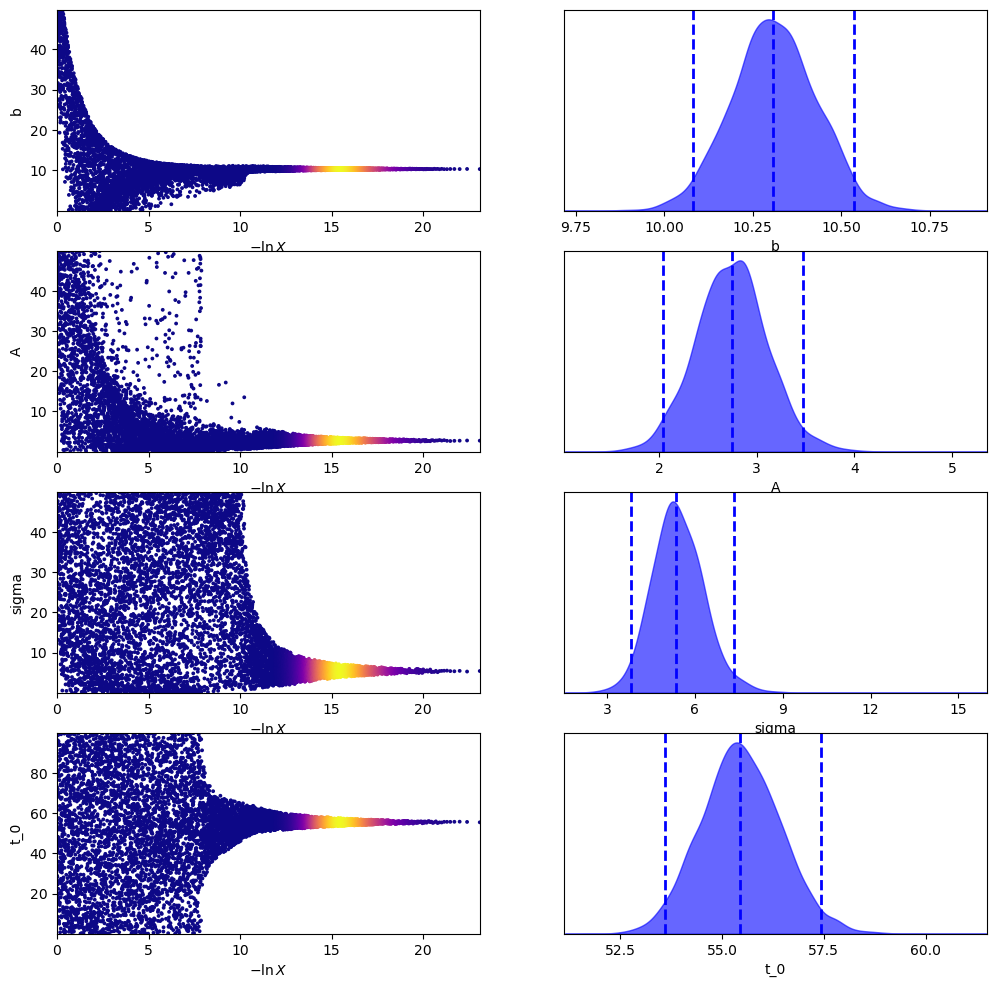

In [13]:
labels = ["b", "A", "sigma", "t_0"]
fig, axes = dyplot.traceplot(gauss_sampler.results, labels=labels)
plt.show()

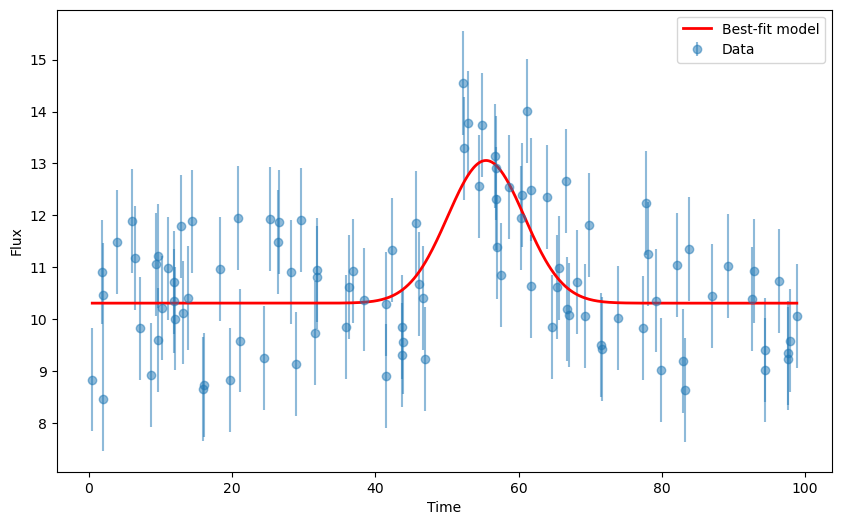

In [14]:
t_fit = np.linspace(time.min(), time.max(), 500)
gauss_weights = np.exp(gauss_sampler.results['logwt'] - gauss_sampler.results['logz'][-1])
gauss_samples_equal = dyfunc.resample_equal(gauss_samples, gauss_weights)
gauss_median_params = np.median(gauss_samples_equal, axis=0)
flux_fit = Model(t_fit, *gauss_median_params)

plt.figure(figsize=(10, 6))
plt.errorbar(time, flux, yerr=error, fmt='o', label='Data', alpha=0.5)
plt.plot(t_fit, flux_fit, color='red', lw=2, label='Best-fit model')
plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.show()

In [17]:
evidence_exp = np.exp(sampler.results['logz'][-1])
evidence_gauss = np.exp(gauss_sampler.results['logz'][-1])

print(f"Evidence for exponential model: {evidence_exp:.3e}")
print(f"Evidence for Gaussian model: {evidence_gauss:.3e}")

print(f"Bayes factor (Exponential / Gaussian): {evidence_exp / evidence_gauss:.3f}")

Evidence for exponential model: 3.067e-28
Evidence for Gaussian model: 1.626e-30
Bayes factor (Exponential / Gaussian): 188.651


Evidence in favor of the exponential model over the Gaussian model is indicated by a Bayes factor greater than 1. A Bayes factor significantly greater than 1 suggests that the data strongly supports the exponential model compared to the Gaussian model.